# Portuguese Bank Telemarketing Campaign Programming File

This Jupyter Notebook contains the Python coding file for the Bank Telemarketing programming exercise completed during unit 8 and accompanies the written report. 

In [ ]:
# 1. Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (classification_report, accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, precision_recall_curve, roc_auc_score, auc, f1_score)
from imblearn.over_sampling import SMOTE
import warnings 
warnings.filterwarnings('ignore')

# 2. Load Dataset
mma = pd.read_csv('MMA marketing_data_sample.csv')
print(mma.head(25)) # view initial 25 rows

# 3. Retrieve Basic Details and Summaries of Dataset
print(mma.info()) # data types, column names, and no. null values
print(mma.describe()) # summary stats for numerical variables

# Function to Retrieve Summary for All Categorical Variables

def quick_summary(df, cols = None):
    if cols is None:
        cols = df.select_dtypes(include = ['object', 'category']).columns.tolist()
    if isinstance(cols, str):
        cols = [cols]

    for col in cols:
        counts = df[col].value_counts()
        percentages = df[col].value_counts(normalize = True) * 100

        summary = pd.DataFrame({
            'Count': counts, 
            'Percentage': percentages.round(1)
        })

        print(f"\n--- Summary for '{col}' ---")
        print(summary.to_string())
        print(f"Total Rows: {len(df[col])}")

quick_summary(mma) # summary stats for categorical variables

# Obtain Sum of Unknowns for Each Variable
unknown_counts = (mma == 'unknown').sum()
print(unknown_counts[unknown_counts > 0].sort_values(ascending = True))

# 4. Data Cleaning 

mma = mma.rename(columns = {'k':'education', 'y':'outcome'}) # rename columns 
mma.loc[:, 'job'].replace(['admin.'], ['admin'], inplace = True) # clean values 

mma['previously_contacted'] = (mma['pdays'] != 999).astype(int) # encode pdays to binary variable (0 - not contacted before, 1 - contacted before)
mma['outcome'] = (mma['outcome'] == 'yes').astype(int) # encode outcome to binary variable (0 - no, 1 - yes)

cat_vars = ['job', 'marital', 'education', 'contact', 'month', 'day_of_week', 'poutcome', 'default', 'housing', 'loan'] # created cat_vars, num_vars to aid in subsequent analysis and model creation
num_vars = ['age', 'duration', 'campaign', 'pdays', 'previous', 'euribor3m', 'nr.employed', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx'] 


    age            job   marital                    k  default  housing  \
0    30    blue-collar   married             basic.9y       no      yes   
1    39       services    single          high.school       no       no   
2    25       services   married          high.school       no      yes   
3    38       services   married             basic.9y       no  unknown   
4    47         admin.   married    university.degree       no      yes   
5    32       services    single    university.degree       no       no   
6    32         admin.    single    university.degree       no      yes   
7    41   entrepreneur   married    university.degree  unknown      yes   
8    31       services  divorced  professional.course       no       no   
9    35    blue-collar   married             basic.9y  unknown       no   
10   25       services    single             basic.6y  unknown      yes   
11   36  self-employed    single             basic.4y       no       no   
12   36         admin.   

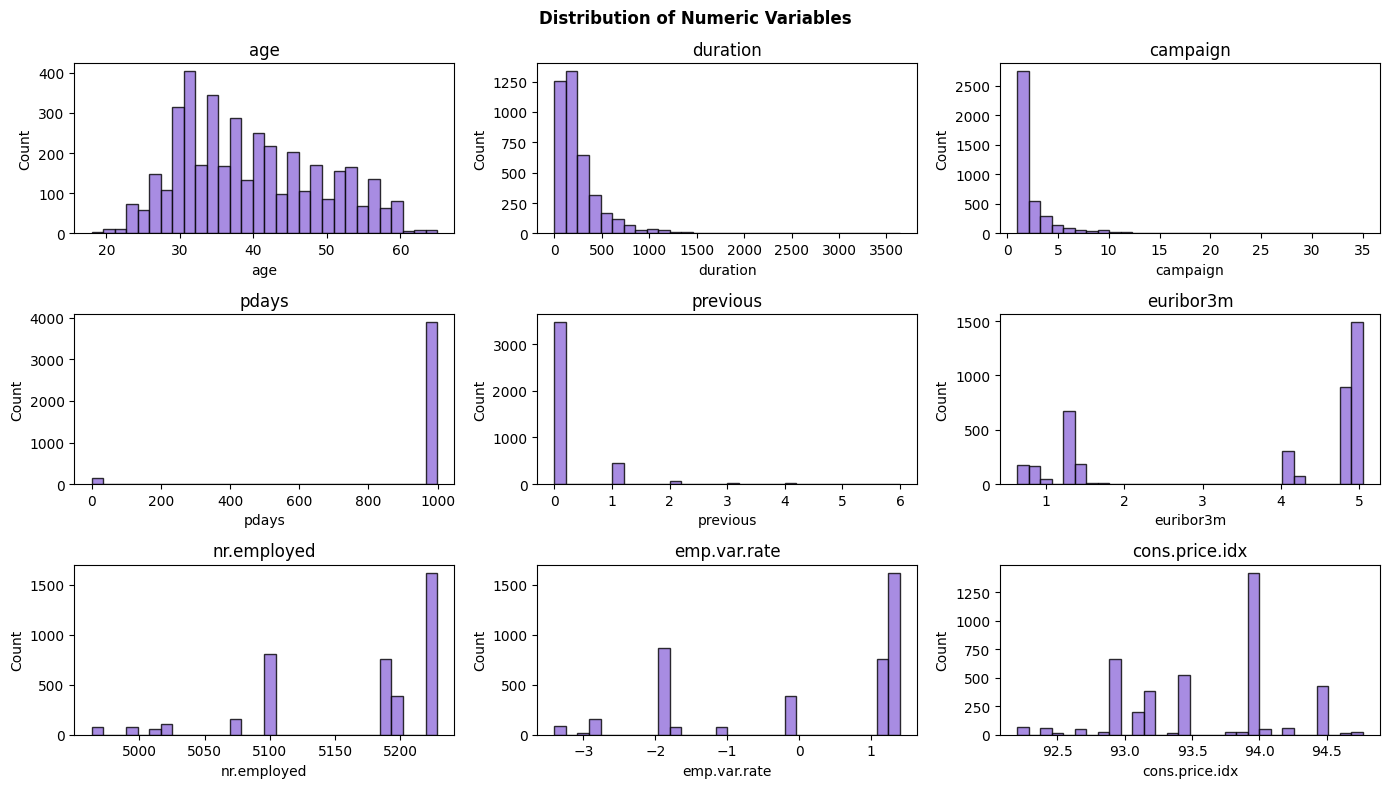

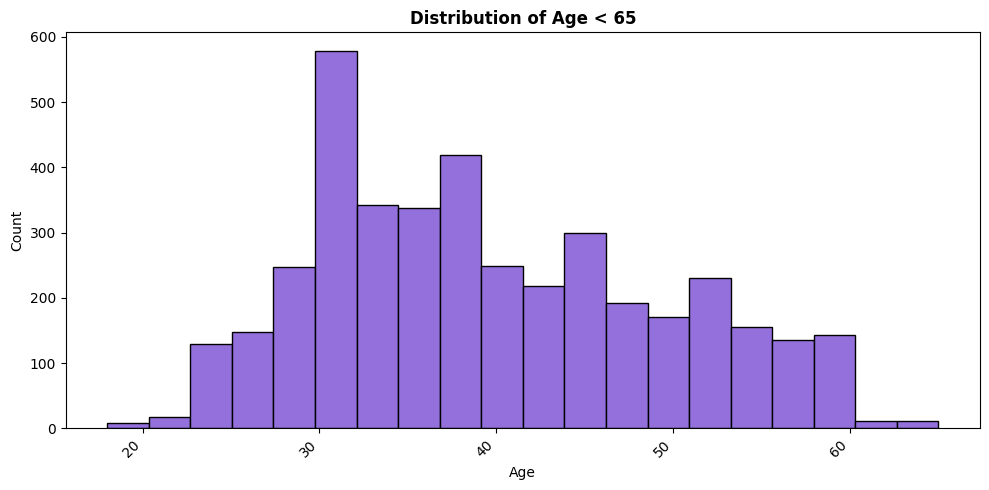

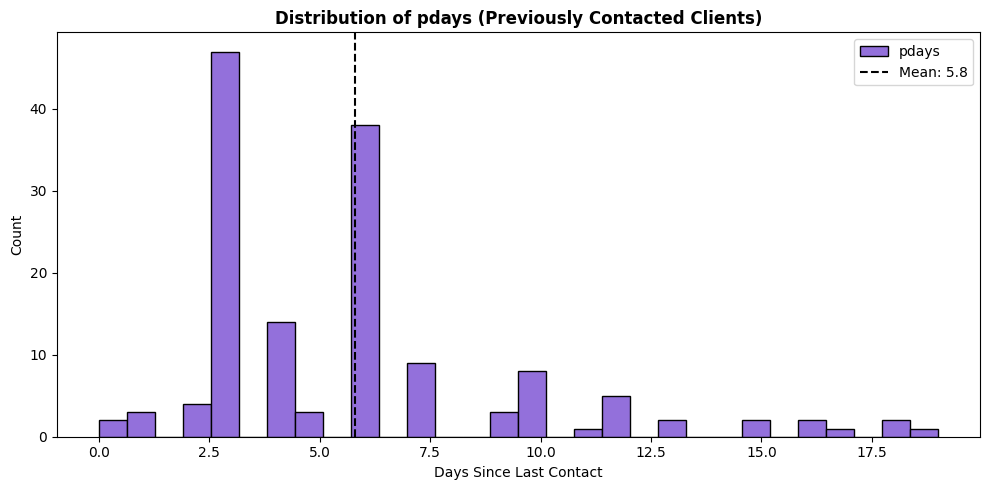

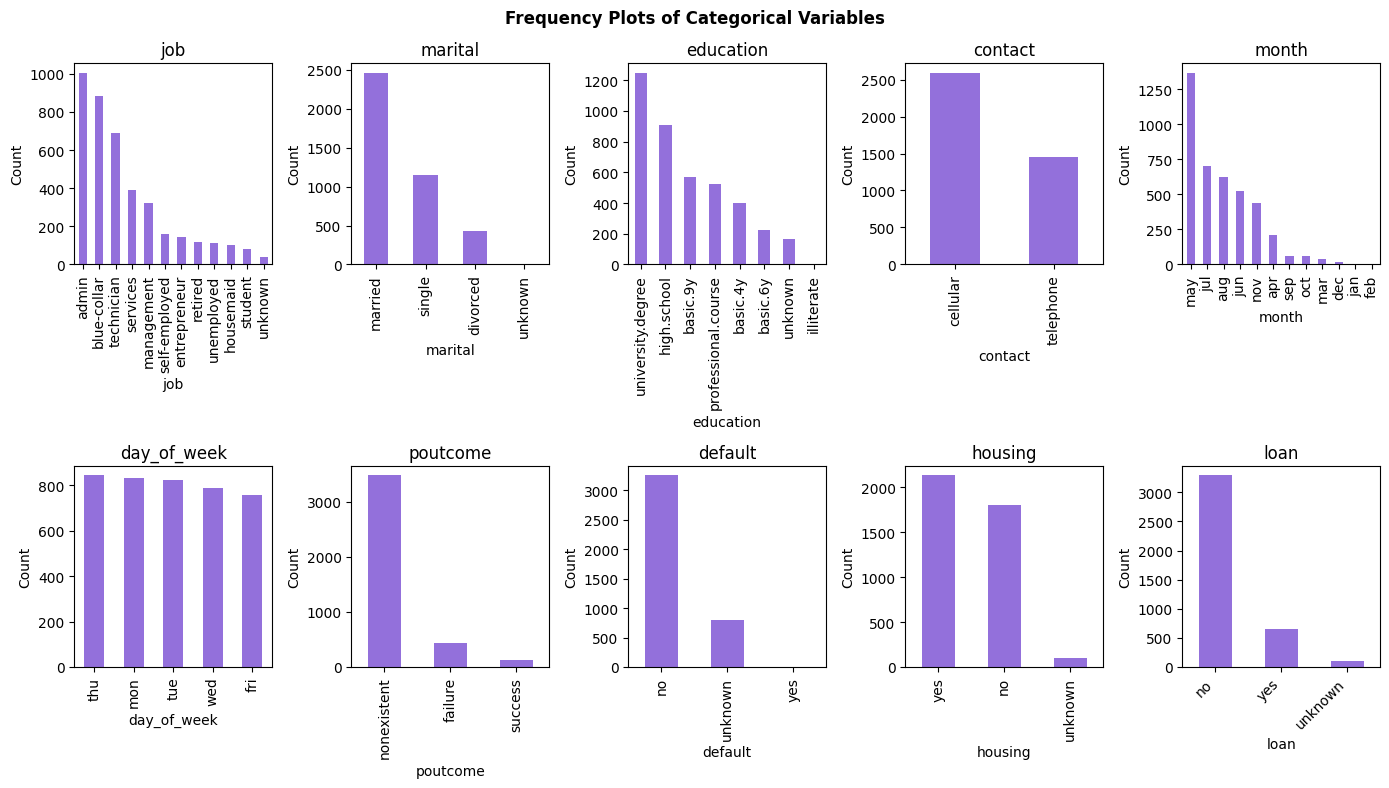

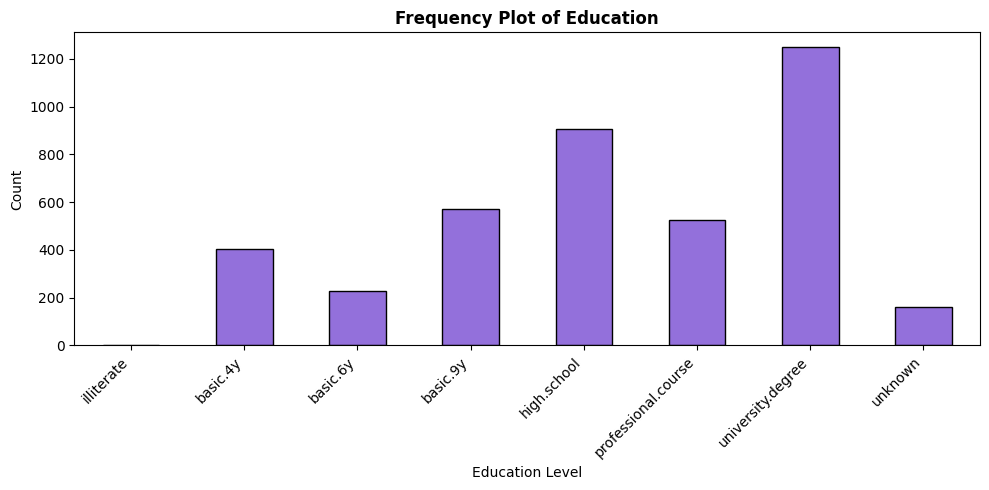

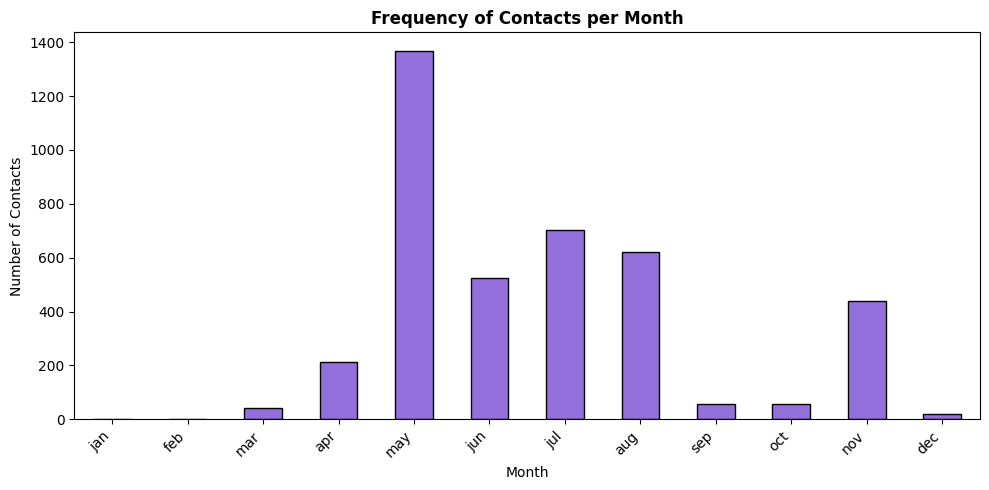

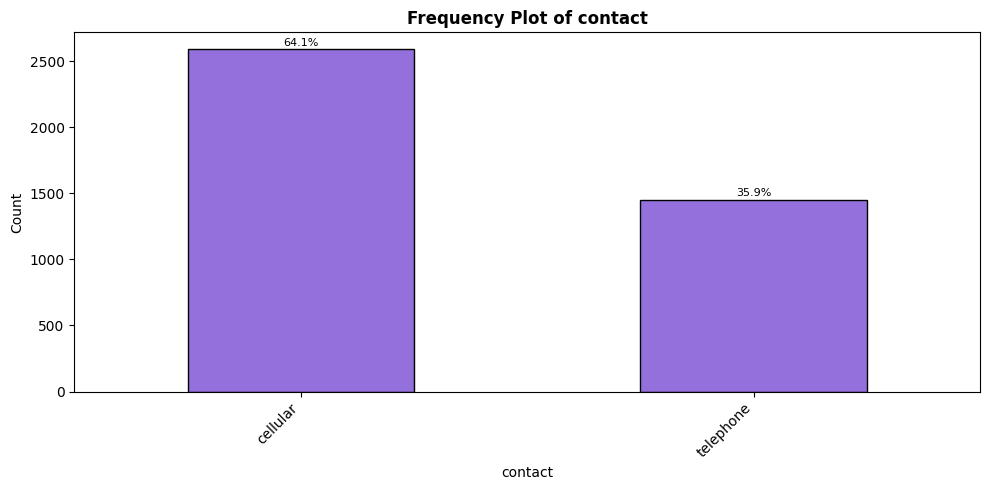

In [ ]:
# 5. Univariate EDA

# Plotting Histograms to Display Distributions of All Numerical Variables 
fig, axes = plt.subplots(3, 3, figsize = (14, 8))
fig.suptitle('Distribution of Numeric Variables', fontsize = 12, fontweight = 'bold')

for ax, col in zip(axes.flatten(), num_vars):
    ax.hist(mma[col], bins = 30, color = 'mediumpurple', edgecolor = 'black', alpha = 0.8)
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel('Count')

plt.tight_layout()
plt.savefig('fig1_numvars_distributions.png', dpi = 150, bbox_inches = 'tight')
plt.show()

# Individual Plot for Age (excluding over 65s)
fig, ax = plt.subplots(figsize = (10, 5))
mma[mma['age'] <= 65]['age'].plot(kind = 'hist', bins = 20, ax = ax, color = 'mediumpurple', edgecolor = 'black')

ax.set_title('Distribution of Age < 65', fontsize = 12, fontweight = 'bold')
ax.set_xlabel('Age')
ax.set_ylabel('Count')
plt.xticks(rotation = 45, ha = 'right')
plt.tight_layout()
plt.savefig('fig2_age_hist.png', dpi = 150, bbox_inches = 'tight')
plt.show()

# Individual Plot for pdays (excluding 999)
pdays_filtered = mma[mma['pdays'] != 999]['pdays']

fig, ax = plt.subplots(figsize = (10, 5))
pdays_filtered.plot(kind = 'hist', bins = 30, ax = ax, color = 'mediumpurple', edgecolor = 'black')

ax.axvline(pdays_filtered.mean(), color = 'black', linestyle = '--', label = f'Mean: {pdays_filtered.mean():.1f}')
ax.set_title('Distribution of pdays (Previously Contacted Clients)', fontsize = 12, fontweight = 'bold')
ax.set_xlabel('Days Since Last Contact')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig('fig3_pdays_hist.png', dpi = 150, bbox_inches = 'tight')
plt.show()

# Plotting Frequency Plots of All Categorical Variables
fig, axes = plt.subplots(2, 5, figsize = (14, 8))
fig.suptitle('Frequency Plots of Categorical Variables', fontsize = 12, fontweight = 'bold')

for ax, col in zip(axes.flatten(), cat_vars):
    mma[col].value_counts().plot(kind = 'bar', ax = ax, color = 'mediumpurple')
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel('Count')

plt.xticks(rotation = 45, ha = 'right')
plt.tight_layout()
plt.savefig('fig4_catvars_frequencies.png', dpi = 150, bbox_inches = 'tight')
plt.show()

# Individual Bar Plot for Education (in ascending order)
education_ordered = ['illiterate', 'basic.4y', 'basic.6y', 'basic.9y', 'high.school', 'professional.course', 'university.degree', 'unknown']
mma['education'] = pd.Categorical(mma['education'], categories = education_ordered, ordered = True)

fig, ax = plt.subplots(figsize = (10,5))
mma['education'].value_counts().sort_index().plot(kind = 'bar', ax = ax, color = 'mediumpurple', edgecolor = 'black')

ax.set_title('Frequency Plot of Education', fontsize = 12, fontweight = 'bold')
ax.set_xlabel('Education Level')
ax.set_ylabel('Count')
plt.xticks(rotation = 45, ha = 'right')
plt.tight_layout()
plt.savefig('fig5_education_freq.png', dpi = 150, bbox_inches = 'tight')
plt.show()

# Individual Bar Plot for Month (in order)
month_ordered = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
mma['month'] = pd.Categorical(mma['month'], categories = month_ordered, ordered = True)
month_counts = mma['month'].value_counts().sort_index()

fig, ax = plt.subplots(figsize = (10,5))
month_counts.plot(kind = 'bar', ax = ax, color = 'mediumpurple', edgecolor = 'black')
ax.set_title('Frequency of Contacts per Month', fontsize = 12, fontweight = 'bold')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Contacts')
plt.xticks(rotation = 45, ha = 'right')
plt.tight_layout()
plt.savefig('fig6_month_freq.png', dpi = 150, bbox_inches = 'tight')
plt.show()

# Function to Create Singular Categorical Plot for Further Analysis 
def plot_categorical(df, col, fignum):

    counts = df[col].value_counts().sort_index()
    percentages = counts / counts.sum() * 100

    fig, ax = plt.subplots(figsize = (10, 5))
    counts.plot(kind = 'bar', ax = ax, color = 'mediumpurple', edgecolor = 'black')

    for i, (count, pct) in enumerate(zip(counts, percentages)):
        ax.text(i, count + 10, f'{pct:.1f}%', ha = 'center', va = 'bottom', fontsize = 8)

    ax.set_title(f'Frequency Plot of {col}', fontsize = 12, fontweight = 'bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    plt.xticks(rotation = 45, ha = 'right')
    plt.tight_layout()
    plt.savefig(f'fig{fignum}_{col}_freqplot.png', dpi = 150, bbox_inches = 'tight')
    plt.show()

plot_categorical(mma, 'contact', 7) # create categorical plot for contact variable 

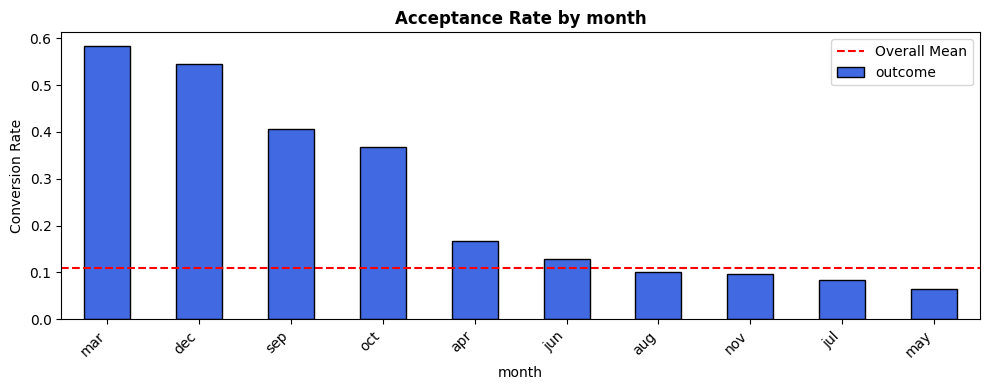

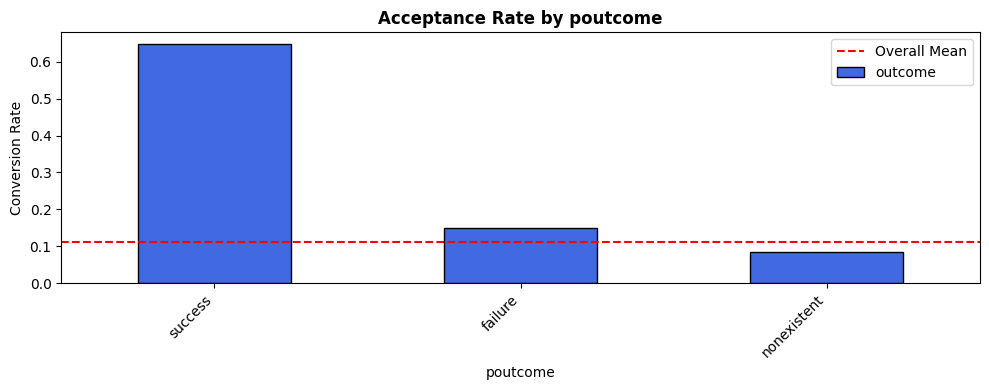

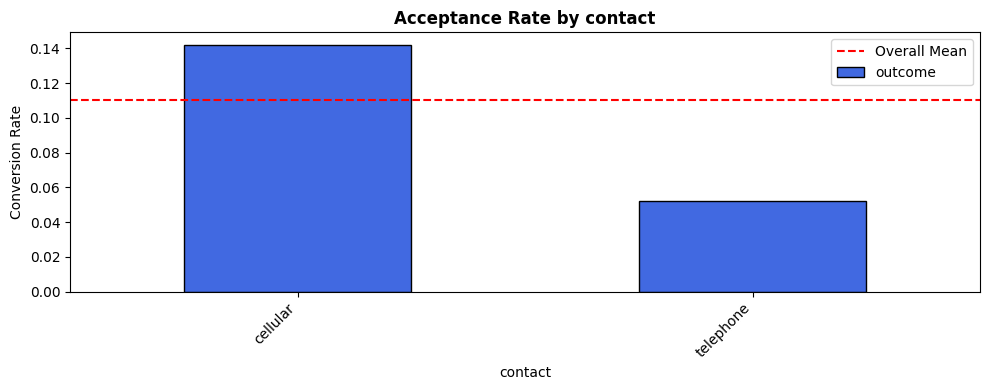

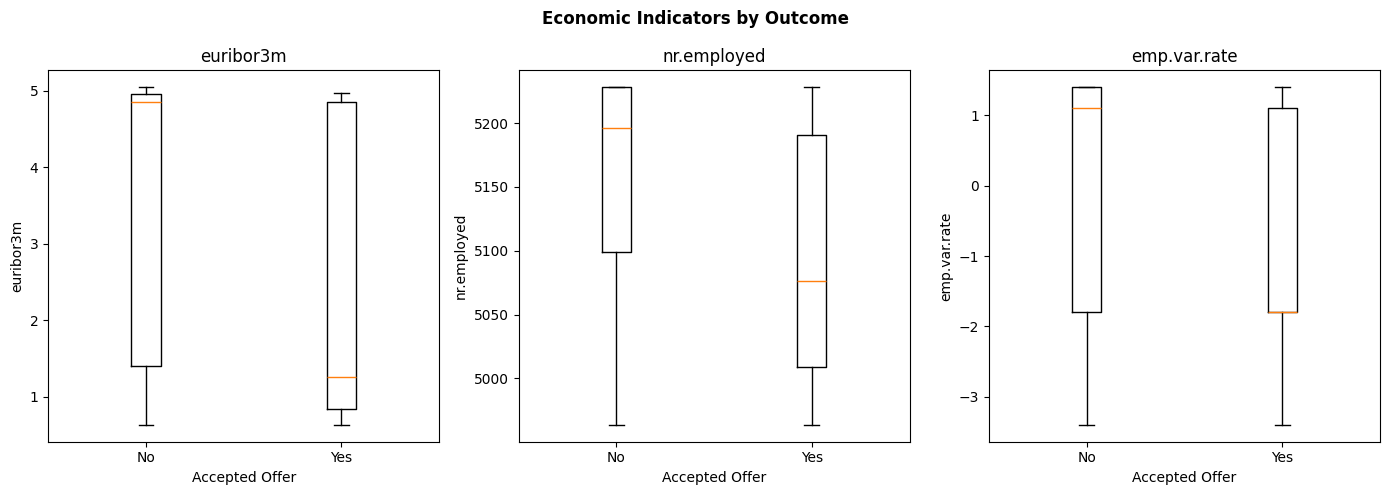

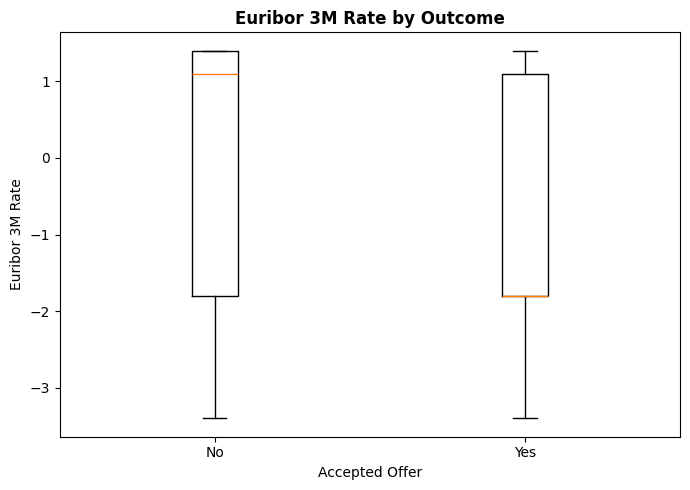

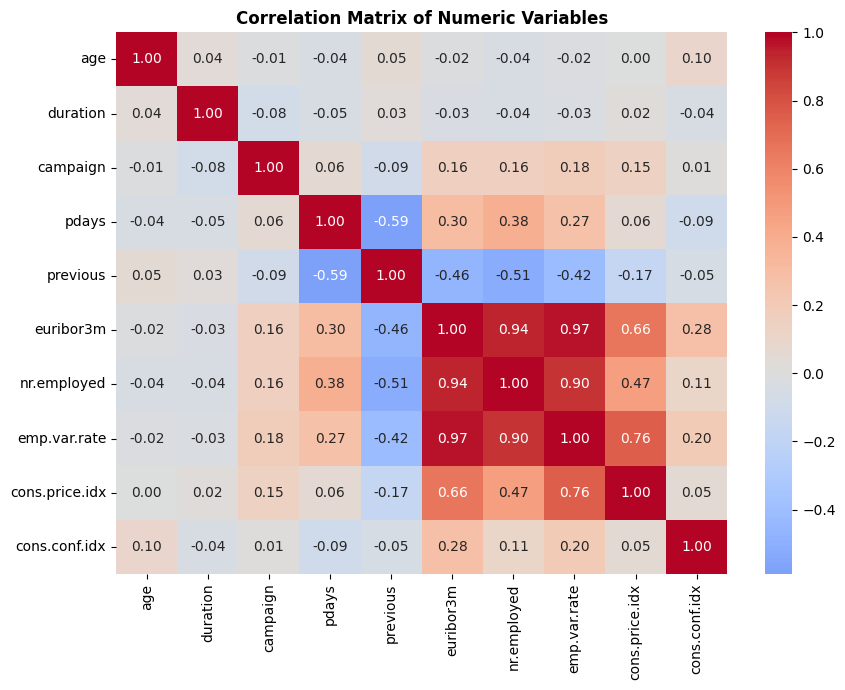

In [ ]:
# 6. Bivariate EDA

# Plotting Conversion Rate by Variable

def plot_conversion_rate(df, col, fignum): # Function created to streamline code
    conv = df.groupby(col)['outcome'].mean().sort_values(ascending = False)

    fig, ax = plt.subplots(figsize = (10,4))
    conv.plot(kind = 'bar', ax = ax, color = 'royalblue', edgecolor = 'black')

    ax.set_title(f'Acceptance Rate by {col}', fontsize = 12, fontweight = 'bold')
    ax.set_ylabel('Conversion Rate')
    ax.set_xlabel(col)
    ax.axhline(df['outcome'].mean(), color = 'red', linestyle = '--', label = 'Overall Mean') # include line showing mean acceptance rate 
    ax.legend()
    plt.xticks(rotation = 45, ha = 'right')
    plt.tight_layout()
    plt.savefig(f'fig{fignum}_{col}_conv.png', dpi = 150, bbox_inches = 'tight')
    plt.show()

plot_conversion_rate(mma, 'month', 7) # bar plot for month
plot_conversion_rate(mma, 'poutcome', 8) # bar plot for poutcome
plot_conversion_rate(mma, 'contact', 9) # bar plot for contact

# Box Plots for Economic Indicators - euribor3m, nr.employed, emp.var.rate

fig, axes = plt.subplots(1, 3, figsize = (14, 5))
axes = axes.flatten()

for ax, col in zip(axes, ['euribor3m', 'nr.employed', 'emp.var.rate']):
    data0 = mma[mma['outcome'] == 0][col]
    data1 = mma[mma['outcome'] == 1][col]
    ax.boxplot([data0, data1], labels = ['No', 'Yes'])
    ax.set_title(col)
    ax.set_xlabel('Accepted Offer')
    ax.set_ylabel(col)

plt.suptitle('Economic Indicators by Outcome', fontsize = 12, fontweight = 'bold')
plt.tight_layout()
plt.savefig('fig10_economic_by_outcome.png', dpi = 150, bbox_inches = 'tight')
plt.show()

# Singular Box Plot for euribor3m

fig, ax = plt.subplots(figsize=(7, 5))

data0 = mma[mma['outcome'] == 0][col]
data1 = mma[mma['outcome'] == 1][col]
ax.boxplot([data0, data1], labels=['No', 'Yes'])
ax.set_title('Euribor 3M Rate by Outcome', fontsize = 12, fontweight = 'bold')
ax.set_xlabel('Accepted Offer')
ax.set_ylabel('Euribor 3M Rate')
plt.tight_layout()
plt.savefig('fig11_euribor3m.png', dpi = 150, bbox_inches = 'tight')
plt.show()

# Correlation Matrix between Numerical Variables 

corr_matrix = mma[num_vars].corr()

plt.figure(figsize = (9, 7))
sns.heatmap(corr_matrix, annot = True, fmt = '.2f', cmap = 'coolwarm', center = 0)
plt.title('Correlation Matrix of Numeric Variables', fontsize = 12, fontweight = 'bold')
plt.tight_layout()
plt.savefig('fig12_corrmatrix.png', dpi = 150, bbox_inches = 'tight')
plt.show()

Train Class Balance: outcome_binary
0    0.89
1    0.11
Name: proportion, dtype: float64
Test Class Balance: outcome_binary
0    0.89
1    0.11
Name: proportion, dtype: float64
             Approach  Accuracy  Precision  Recall    F1
class_weight=balanced     0.883      0.468   0.859 0.606
                SMOTE     0.494      0.114   0.565 0.190
              precision    recall  f1-score   support

          No       0.98      0.89      0.93       724
         Yes       0.47      0.86      0.61        85

    accuracy                           0.88       809
   macro avg       0.72      0.87      0.77       809
weighted avg       0.93      0.88      0.90       809

{'accuracy': 0.883, 'precision': 0.468, 'recall': 0.859, 'f1': 0.606, 'auc': 0.932}
              precision    recall  f1-score   support

          No       0.95      0.86      0.90       724
         Yes       0.33      0.60      0.43        85

    accuracy                           0.83       809
   macro avg       0.64

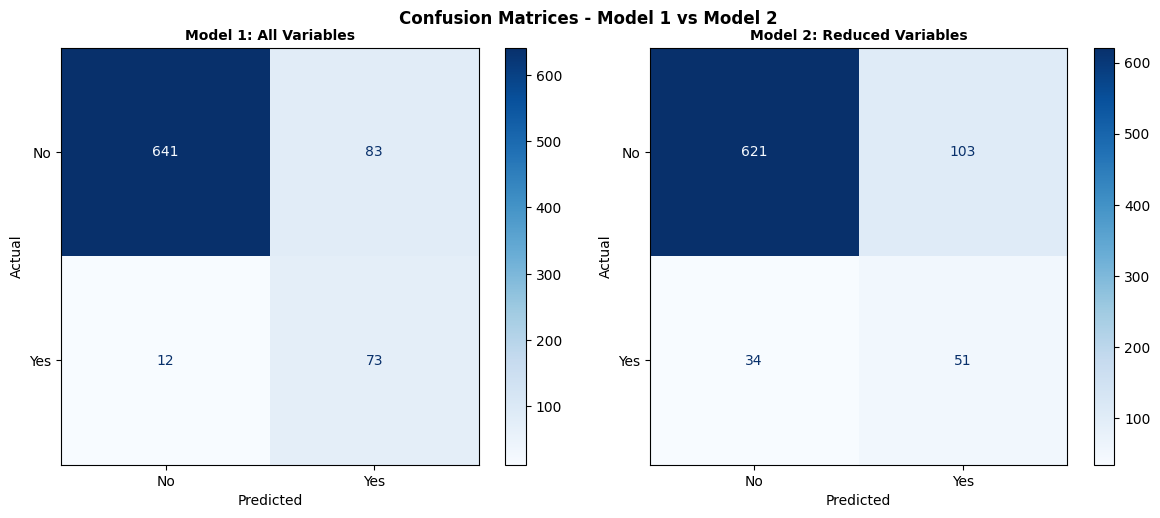

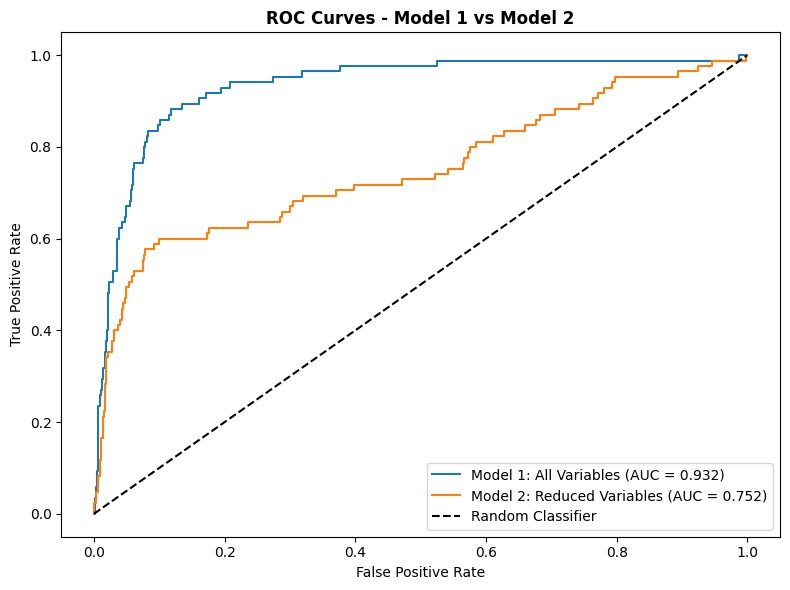

In [66]:
# 7. Model Development 

# Preprocessing

mma = mma[mma['age'] <= 65] # omitting over 65's from final dataset + optional print(mma.describe()) to check mean age

cat_vars = ['job', 'marital', 'education', 'contact', 'month', 'day_of_week', 'poutcome', 'default', 'housing', 'loan']
mma_encode = pd.get_dummies(mma, columns = cat_vars, drop_first = True) # encode variables
mma_encode['outcome_binary'] = mma_encode['outcome']

# Creating Stratified Train/Test Split
mma_encode['outcome_binary'] = mma_encode['outcome']
X = mma_encode.drop(columns = ['outcome', 'outcome_binary'])
y = mma_encode['outcome_binary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42, stratify = y
)

scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns = X_train.columns)
X_test  = pd.DataFrame(scaler.transform(X_test), columns = X_test.columns)

print('Train Class Balance:', y_train.value_counts(normalize = True).round(2)) #confirming class imbalance for train & test
print('Test Class Balance:', y_test.value_counts(normalize = True).round(2))

# Comparison of Methods to Balance Classes

    # Class_weight
lr_balanced = LogisticRegression(class_weight = 'balanced', max_iter = 1000, random_state = 42)
lr_balanced.fit(X_train, y_train)
y_pred_balanced = lr_balanced.predict(X_test)

    # SMOTE + Standard Logistic Regression

X1 = mma_encode.drop(columns = ['outcome', 'outcome_binary'])
y1 = mma_encode['outcome_binary']

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size = 0.2, random_state = 42, stratify = y
)

smote = SMOTE(random_state=42)
X1_train_sm, y1_train_sm = smote.fit_resample(X1_train, y1_train)

lr_smote = LogisticRegression(max_iter = 1000, random_state = 42)
lr_smote.fit(X1_train_sm, y1_train_sm)
y_pred_smote = lr_smote.predict(X_test)

    # Comparison Table
results = pd.DataFrame({
    'Approach':  ['class_weight=balanced', 'SMOTE'],
    'Accuracy':  [accuracy_score(y_test, y_pred_balanced),  accuracy_score(y_test, y_pred_smote)],
    'Precision': [precision_score(y_test, y_pred_balanced), precision_score(y_test, y_pred_smote)],
    'Recall':    [recall_score(y_test, y_pred_balanced),    recall_score(y_test, y_pred_smote)],
    'F1':        [f1_score(y_test, y_pred_balanced),        f1_score(y_test, y_pred_smote)],
}).round(3)

print(results.to_string(index=False)) 

# Function to Evaluate Models

def evaluate_model(model, X_test, y_test):
    y_predict = model.predict(X_test)
    y_probability = model.predict_proba(X_test)[:, 1]

    print(classification_report(y_test, y_predict, target_names = ['No', 'Yes']))

    return {
        'accuracy': round(accuracy_score(y_test, y_predict), 3), 
        'precision': round(precision_score(y_test, y_predict), 3), 
        'recall': round(recall_score(y_test, y_predict), 3),
        'f1': round(f1_score(y_test, y_predict), 3), 
        'auc': round(roc_auc_score(y_test, y_probability), 3)
    }

# Logistic Regression - Model 1 with All Variables
model1 = LogisticRegression(class_weight = 'balanced', max_iter = 1000, random_state = 42)
model1.fit(X_train, y_train)
y_predict_model1 = model1.predict(X_test)

model1_results = evaluate_model(model1, X_test, y_test)
print(model1_results)

# Logistic Regression - Model 2 excluding Identified Variables. Improving Model by Removing Irrelevant Variables 

cols_to_drop = ['outcome', 'outcome_binary', 'nr.employed', 'emp.var.rate', 'duration'] + \
               [col for col in mma_encode.columns if col.startswith('default')] + \
               [col for col in mma_encode.columns if col.startswith('day_of_week')] + \
               [col for col in mma_encode.columns if col.startswith('poutcome')]


X2 = mma_encode.drop(columns=cols_to_drop)

X2_train, X2_test, y_train, y_test = train_test_split(
    X2, y, test_size = 0.2, random_state = 42, stratify = y
)

scaler = StandardScaler()
X2_train = pd.DataFrame(scaler.fit_transform(X2_train), columns = X2_train.columns)
X2_test  = pd.DataFrame(scaler.transform(X2_test), columns = X2_test.columns)

model2 = LogisticRegression(class_weight = 'balanced', max_iter = 1000, random_state = 42)
model2.fit(X2_train, y_train)
y_predict_model2 = model2.predict(X2_test)

model2_results = evaluate_model(model2, X2_test, y_test)
print(model2_results)

# 8. Model Evaluation

# Plotting Confusion Matrices for Both Models 

fig, axes = plt.subplots(1, 2, figsize = (12,5))
axes = axes.flatten()

matrix1 = confusion_matrix(y_test, y_predict_model1)
display1 = ConfusionMatrixDisplay(matrix1, display_labels = ['No', 'Yes'])
display1.plot(ax = axes[0], cmap = 'Blues')
axes[0].set_title('Model 1: All Variables', fontsize = 10, fontweight = 'bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

matrix2 = confusion_matrix(y_test, y_predict_model2)
display2 = ConfusionMatrixDisplay(matrix2, display_labels = ['No', 'Yes'])
display2.plot(ax = axes[1], cmap = 'Blues')
axes[1].set_title('Model 2: Reduced Variables', fontsize = 10, fontweight = 'bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.suptitle('Confusion Matrices - Model 1 vs Model 2', fontsize = 12, fontweight = 'bold')
plt.tight_layout()
plt.savefig('fig13_confusion_matrix.png', dpi = 150, bbox_inches = 'tight')
plt.show()

# Plotting ROC for Both Models
fig, ax = plt.subplots(figsize = (8, 6))

y_prob_model1 = model1.predict_proba(X_test)[:, 1]
fpr1, tpr1, _ = roc_curve(y_test, y_prob_model1)
auc1 = auc(fpr1, tpr1)
ax.plot(fpr1, tpr1, label = f'Model 1: All Variables (AUC = {auc1:.3f})')

y_prob_model2 = model2.predict_proba(X2_test)[:, 1]
fpr2, tpr2, _ = roc_curve(y_test, y_prob_model2)
auc2 = auc(fpr2, tpr2)
ax.plot(fpr2, tpr2, label = f'Model 2: Reduced Variables (AUC = {auc2:.3f})')

ax.plot([0, 1], [0, 1], 'k--', label = 'Random Classifier')
ax.set_title('ROC Curves - Model 1 vs Model 2', fontsize = 12, fontweight = 'bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend()
plt.tight_layout()
plt.savefig('fig14_ROC_curves.png', dpi = 150, bbox_inches = 'tight')
plt.show()